<h1 style="background-color: #FAF9F6; font-family: newtimroman; font-size: 250%; color: darkblue; border: 12px solid #A9A9A9; border-radius: 20px; padding: 15px; text-align: center;">
    <b>AutoScout Project</b>
</h1>


## Determines

**Auto Scout** data which using for this project, scraped from the on-line car trading company(https://www.autoscout24.com)in 2019, contains many features of 9 different car models. In this project, you will use the data set which is already preprocessed and prepared for algorithms .

The aim of this project to understand of machine learning algorithms. Therefore, you will not need any EDA process as you will be working on the edited data.

---

In this Senario, you will estimate the prices of cars using regression algorithms.

While starting you should import the necessary modules and load the data given as pkl file. Also you'll need to do a few pre-processing before moving to modelling. After that you will implement ***Linear Regression, Ridge Regression, Lasso Regression,and Elastic-Net algorithms respectively*** (After completion of Unsupervised Learning section, you can also add bagging and boosting algorithms such as ***Random Forest and XG Boost*** this notebook to develop the project. You can measure the success of your models with regression evaluation metrics as well as with cross validation method.

For the better results, you should try to increase the success of your models by performing hyperparameter tuning. Determine feature importances for the model. You can set your model with the most important features for resource saving. You should try to apply this especially in Random Forest and XG Boost algorithms. Unlike the others, you will perform hyperparameter tuning for Random Forest and XG Boost using the ***GridSearchCV*** method. 

Finally You can compare the performances of algorithms, work more on the algorithm have the most successful prediction rate.



1. **make_model:** Contains the make and model information of the vehicles.
2. **body_type:** Indicates the body type of the vehicles (e.g., sedan, hatchback).
3. **price:** Contains the price information of the vehicles.
4. **vat:** Contains value-added tax (VAT) information (often important in vehicle sales).
5. **km:** Contains the mileage information of the vehicles.
6. **type:** Indicates the type of the vehicle (e.g., new, used).
7. **fuel:** Indicates the type of fuel used (e.g., petrol, diesel).
8. **gears:** Contains the number of gears in the vehicles.
9. **comfort_convenience:** Contains the comfort and convenience features of the vehicles.
10. **entertainment_media:** Contains entertainment and media features.
11. **extras:** Contains the extra features of the vehicles.
12. **safety_security:** Contains safety features.
13. **age:** The age of the vehicles.
14. **previous_owners:** Contains the number of previous owners of the vehicles.
15. **hp_kw:** Contains the horsepower of the vehicles in kilowatts.
16. **inspection:** Contains information about whether the vehicle has a new inspection.
17. **paint_type:** Contains the type of paint of the vehicles.
18. **upholstery_type:** Contains the type of upholstery in the vehicles.
19. **gearing_type:** Indicates the type of transmission in the vehicles.
20. **cc:** Indicates the engine displacement in cubic centimeters (cc).
21. **weight_kg:** Indicates the weight of the vehicles in kilograms.
22. **drive_chain:** Indicates the type of drive train in the vehicles (e.g., front-wheel drive, rear-wheel drive).
23. **cons_comb:** Indicates the combined fuel consumption of the vehicles in liters per 100 kilometers.



make_model: Araçların marka ve model bilgilerini içerir.

body_type: Araçların gövde tipini belirtir (örneğin, sedan, hatchback).

price: Araçların fiyat bilgilerini içerir.

vat: Katma Değer Vergisi (KDV) bilgilerini içerir (araç satışlarında genellikle önemlidir).

km: Araçların kilometre bilgilerini içerir.

type: Araç tipini belirtir (örneğin, yeni, ikinci el).

fuel: Kullanılan yakıt türünü belirtir (örneğin, benzin, dizel).

gears: Araçlardaki vites sayısını içerir.

comfort_convenience: Araçların konfor ve kullanım kolaylığı özelliklerini içerir.

entertainment_media: Eğlence ve medya özelliklerini içerir.

extras: Araçların ekstra özelliklerini içerir.

safety_security: Güvenlik özelliklerini içerir.

age: Araçların yaşını belirtir.

previous_owners: Araçların önceki sahiplerinin sayısını içerir.

hp_kw: Araçların beygir gücünü kilovat cinsinden içerir.

inspection: Araçta yeni bir muayene olup olmadığı bilgisini içerir.

paint_type: Araçların boya türünü içerir.

upholstery_type: Araçlardaki döşeme türünü içerir.

gearing_type: Şanzıman tipini belirtir.

cc: Motor hacmini santimetreküp (cc) olarak belirtir.

weight_kg: Araçların kilogram cinsinden ağırlığını belirtir.

drive_chain: Araçların aktarma organı tipini belirtir (örneğin, önden çekiş, arkadan itiş).

cons_comb: Araçların 100 kilometredeki ortalama yakıt tüketimini litre olarak belirtir.

# #Tasks

#### 1. Import Modules, Load Data and Data Review
#### 2. Data Pre-Processing
#### 3. Implement Linear Regression 
#### 4. Implement Ridge Regression
#### 5. Implement Lasso Regression 
#### 6. Implement Elastic-Net
#### 7. Visually Compare Models Performance In a Graph

## 1. Import Modules, Load Data and Data Review

<div class="alert alert-warning alert-info" style="background-color: #FAF9F6; border: 5px solid #A9A9A9; border-radius: 10px;">
    <h3 style="font-weight: bold; color: darkblue;">Import Libraries and Read the Data</h3>
</div>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
%matplotlib inline
#%matplotlib notebook

import warnings
warnings.filterwarnings('ignore')
plt.rcParams["figure.figsize"] = (10,6)
pd.set_option('display.max_columns', 100)

import scipy.stats as stats
import inflection
from skimpy import clean_columns
import missingno as msno
import plotly.graph_objects as go
from scipy.stats import skew

In [2]:
df = pd.read_csv("final_scout_not_dummy.csv")
df.sample(10)

,make_model,body_type,price,vat,km,Type,Fuel,Gears,Comfort_Convenience,Entertainment_Media,Extras,Safety_Security,age,Previous_Owners,hp_kW,Inspection_new,Paint_Type,Upholstery_type,Gearing_Type,Displacement_cc,Weight_kg,Drive_chain,cons_comb
7668,Opel Astra,Sedans,29850,VAT deductible,10.0,Pre-registered,Benzine,6.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,Digital radio,Hands-free equipment,M...","Alloy wheels,Catalytic Converter,Sport package...","ABS,Adaptive Cruise Control,Adaptive headlight...",0.0,1.0,110.0,1,Metallic,Part/Full Leather,Automatic,1398.0,1273.0,front,5.5
2192,Audi A1,Sedans,21490,VAT deductible,10.0,Used,Benzine,5.0,"Air conditioning,Automatic climate control,Cru...","CD player,Hands-free equipment,Radio,Sound system",Alloy wheels,"Electronic stability control,Emergency brake a...",0.0,1.0,70.0,0,Metallic,Cloth,Manual,999.0,1138.0,front,4.6
13378,Renault Clio,Sedans,10000,VAT deductible,70000.0,Used,Diesel,6.0,"Cruise control,Electrical side mirrors,Power w...",On-board computer,Alloy wheels,"ABS,Central door lock,Daytime running lights,D...",3.0,1.0,66.0,0,Metallic,Part/Full Leather,Automatic,1500.0,1165.0,front,5.0
14998,Renault Espace,Van,25999,VAT deductible,24433.0,Used,Diesel,6.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,Hands-free equipment,On-board comput...",Alloy wheels,"ABS,Blind spot monitor,Central door lock,Dayti...",2.0,1.0,118.0,0,Metallic,Part/Full Leather,Automatic,1598.0,1659.0,front,4.0
8479,Opel Corsa,Compact,10990,VAT deductible,20325.0,Used,Benzine,6.0,"Air conditioning,Cruise control,Electrical sid...","Bluetooth,Hands-free equipment,On-board comput...","Alloy wheels,Touch screen","ABS,Central door lock,Daytime running lights,D...",2.0,2.0,66.0,0,Metallic,Cloth,Automatic,1398.0,1163.0,front,5.9
13181,Renault Clio,Compact,15485,VAT deductible,21939.0,Employee's car,Benzine,6.0,"Air conditioning,Automatic climate control,Cru...","Hands-free equipment,On-board computer,Radio","Alloy wheels,Touch screen","ABS,Central door lock,Daytime running lights,D...",1.0,1.0,87.0,1,Metallic,Part/Full Leather,Automatic,1197.0,1154.0,front,5.4
13356,Renault Clio,Station wagon,11500,VAT deductible,32713.0,Used,Diesel,6.0,"Air conditioning,Cruise control,Electrically a...",On-board computer,"Alloy wheels,Roof rack","ABS,Central door lock,Fog lights,Isofix,Power ...",2.0,1.0,66.0,0,Metallic,Cloth,Automatic,1461.0,1276.0,front,3.4
3465,Audi A3,Sedans,17000,Price negotiable,59000.0,Used,Diesel,6.0,"Air conditioning,Seat ventilation,Split rear s...","Bluetooth,Radio","Alloy wheels,Trailer hitch","ABS,Adaptive Cruise Control,Alarm system,Centr...",3.0,1.0,110.0,0,Metallic,Cloth,Semi-automatic,1968.0,1400.0,front,4.5
9121,Opel Corsa,Sedans,8650,VAT deductible,62115.0,Used,Benzine,5.0,"Air conditioning,Cruise control,Hill Holder,Le...","Bluetooth,CD player,Hands-free equipment,MP3,O...",Alloy wheels,"ABS,Central door lock with remote control,Driv...",2.0,1.0,66.0,1,Metallic,Cloth,Manual,1398.0,1163.0,front,5.7
15139,Renault Espace,Van,23990,VAT deductible,34773.0,Used,Benzine,7.0,"Cruise control,Sunroof","Bluetooth,Hands-free equipment,On-board comput...",Alloy wheels,"ABS,Driver-side airbag,Electronic stability co...",3.0,1.0,147.0,0,Metallic,Part/Full Leather,Automatic,1618.0,2410.0,front,6.2


<div class="alert alert-warning alert-info" style="background-color: #FAF9F6; border: 5px solid #A9A9A9; border-radius: 10px;">
    <h3 style="font-weight: bold; color: darkblue;">EDA</h3>
</div>

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15915 entries, 0 to 15914
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   make_model           15915 non-null  object 
 1   body_type            15915 non-null  object 
 2   price                15915 non-null  int64  
 3   vat                  15915 non-null  object 
 4   km                   15915 non-null  float64
 5   Type                 15915 non-null  object 
 6   Fuel                 15915 non-null  object 
 7   Gears                15915 non-null  float64
 8   Comfort_Convenience  15915 non-null  object 
 9   Entertainment_Media  15915 non-null  object 
 10  Extras               15915 non-null  object 
 11  Safety_Security      15915 non-null  object 
 12  age                  15915 non-null  float64
 13  Previous_Owners      15915 non-null  float64
 14  hp_kW                15915 non-null  float64
 15  Inspection_new       15915 non-null 

In [4]:
df.shape

(15915, 23)

In [5]:
df.columns = df.columns.str.lower()

In [6]:
df.rename({"make_model": "model",
           "entertainment_media": "entertainments",
           "safety_security": "safety",
           "displacement_cc": "cc"}, axis=1, inplace=True)
df.columns

Index(['model', 'body_type', 'price', 'vat', 'km', 'type', 'fuel', 'gears',
       'comfort_convenience', 'entertainments', 'extras', 'safety', 'age',
       'previous_owners', 'hp_kw', 'inspection_new', 'paint_type',
       'upholstery_type', 'gearing_type', 'cc', 'weight_kg', 'drive_chain',
       'cons_comb'],
      dtype='object')

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,15915.0,18024.380584,7381.679318,4950.0,12850.0,16900.0,21900.0,74600.0
km,15915.0,32089.995708,36977.214964,0.0,1920.5,20413.0,46900.0,317000.0
gears,15915.0,5.937355,0.704772,5.0,5.0,6.0,6.0,8.0
age,15915.0,1.389695,1.121306,0.0,0.0,1.0,2.0,3.0
previous_owners,15915.0,1.042853,0.339178,0.0,1.0,1.0,1.0,4.0
hp_kw,15915.0,88.499340,26.674341,40.0,66.0,85.0,103.0,294.0
inspection_new,15915.0,0.247063,0.431317,0.0,0.0,0.0,0.0,1.0
cc,15915.0,1428.661891,275.804272,890.0,1229.0,1461.0,1598.0,2967.0
weight_kg,15915.0,1337.700534,199.682385,840.0,1165.0,1295.0,1472.0,2471.0
cons_comb,15915.0,4.832124,0.867530,3.0,4.1,4.8,5.4,9.1


In [8]:
df.describe(include="object").T

,count,unique,top,freq
model,15915,9,Audi A3,3097
body_type,15915,8,Sedans,8004
vat,15915,2,VAT deductible,15044
type,15915,5,Used,11095
fuel,15915,4,Benzine,8548
comfort_convenience,15915,6196,"Air conditioning,Electrical side mirrors,Hill ...",388
entertainments,15915,346,"Bluetooth,Hands-free equipment,On-board comput...",1737
extras,15915,659,Alloy wheels,5785
safety,15915,4442,"ABS,Central door lock,Daytime running lights,D...",729
paint_type,15915,3,Metallic,15246


In [9]:
missing_count = df.isnull().sum()
value_count = df.isnull().count()
missing_percentage = round(missing_count / value_count * 100, 2)
missing_df = pd.DataFrame({"count": missing_count, "percentage": missing_percentage})
missing_df

,count,percentage
model,0,0.0
body_type,0,0.0
price,0,0.0
vat,0,0.0
km,0,0.0
type,0,0.0
fuel,0,0.0
gears,0,0.0
comfort_convenience,0,0.0
entertainments,0,0.0


In [10]:
df["gears"] = df["gears"].astype("int")
df["previous_owners"] = df["previous_owners"].astype("int")
df["age"] = df["age"].astype("int")
df["hp_kw"] = df["hp_kw"].astype("int")
df["cc"] = df["cc"].astype("int")
df["weight_kg"] = df["weight_kg"].astype("int")

df['km'] = df['km'].round(2)

In [11]:
df.sample(2)

,model,body_type,price,vat,km,type,fuel,gears,comfort_convenience,entertainments,extras,safety,age,previous_owners,hp_kw,inspection_new,paint_type,upholstery_type,gearing_type,cc,weight_kg,drive_chain,cons_comb
2933,Audi A3,Sedans,15980,VAT deductible,70142.0,Used,Diesel,7,"Air conditioning,Automatic climate control,Ele...","Bluetooth,CD player,On-board computer",Alloy wheels,"ABS,Central door lock,Driver-side airbag,Elect...",3,1,81,0,Metallic,Cloth,Automatic,1598,1360,front,4.0
2085,Audi A1,Sedans,24690,VAT deductible,164.0,Demonstration,Benzine,7,"Air conditioning,Power windows",Radio,Alloy wheels,"ABS,Central door lock,Passenger-side airbag,Po...",0,1,85,0,Metallic,Cloth,Automatic,999,1680,front,4.8


<div class="alert alert-warning alert-info" style="background-color: #FAF9F6; border: 5px solid #A9A9A9; border-radius: 10px;">
    <h4 style="font-weight: bold; color: darkblue;">df["model"]</h4>
</div>

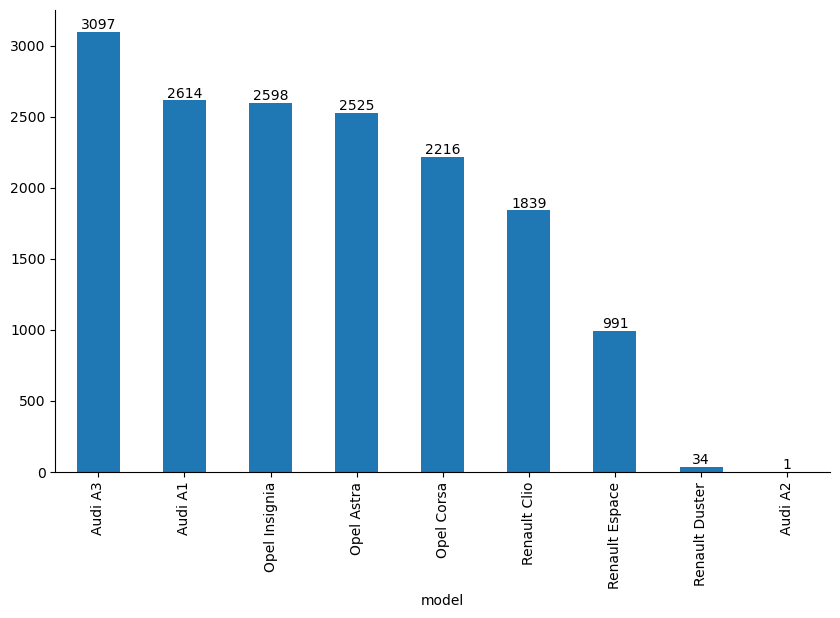

In [12]:
ax = df.model.value_counts().plot(kind ="bar")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
#ax.axis("off")
    
ax.bar_label(ax.containers[0]);

In [13]:
# Drop "Audi A2"

df[df.model == "Audi A2"]

,model,body_type,price,vat,km,type,fuel,gears,comfort_convenience,entertainments,extras,safety,age,previous_owners,hp_kw,inspection_new,paint_type,upholstery_type,gearing_type,cc,weight_kg,drive_chain,cons_comb
2614,Audi A2,Off-Road,28200,VAT deductible,26166.0,Employee's car,Diesel,6,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,CD player,Hands-free equipment,MP3,O...",Alloy wheels,"ABS,Adaptive Cruise Control,Central door lock,...",1,1,85,0,Metallic,Cloth,Manual,1598,1135,front,4.9


In [14]:
df.drop(index=[2614], inplace=True)

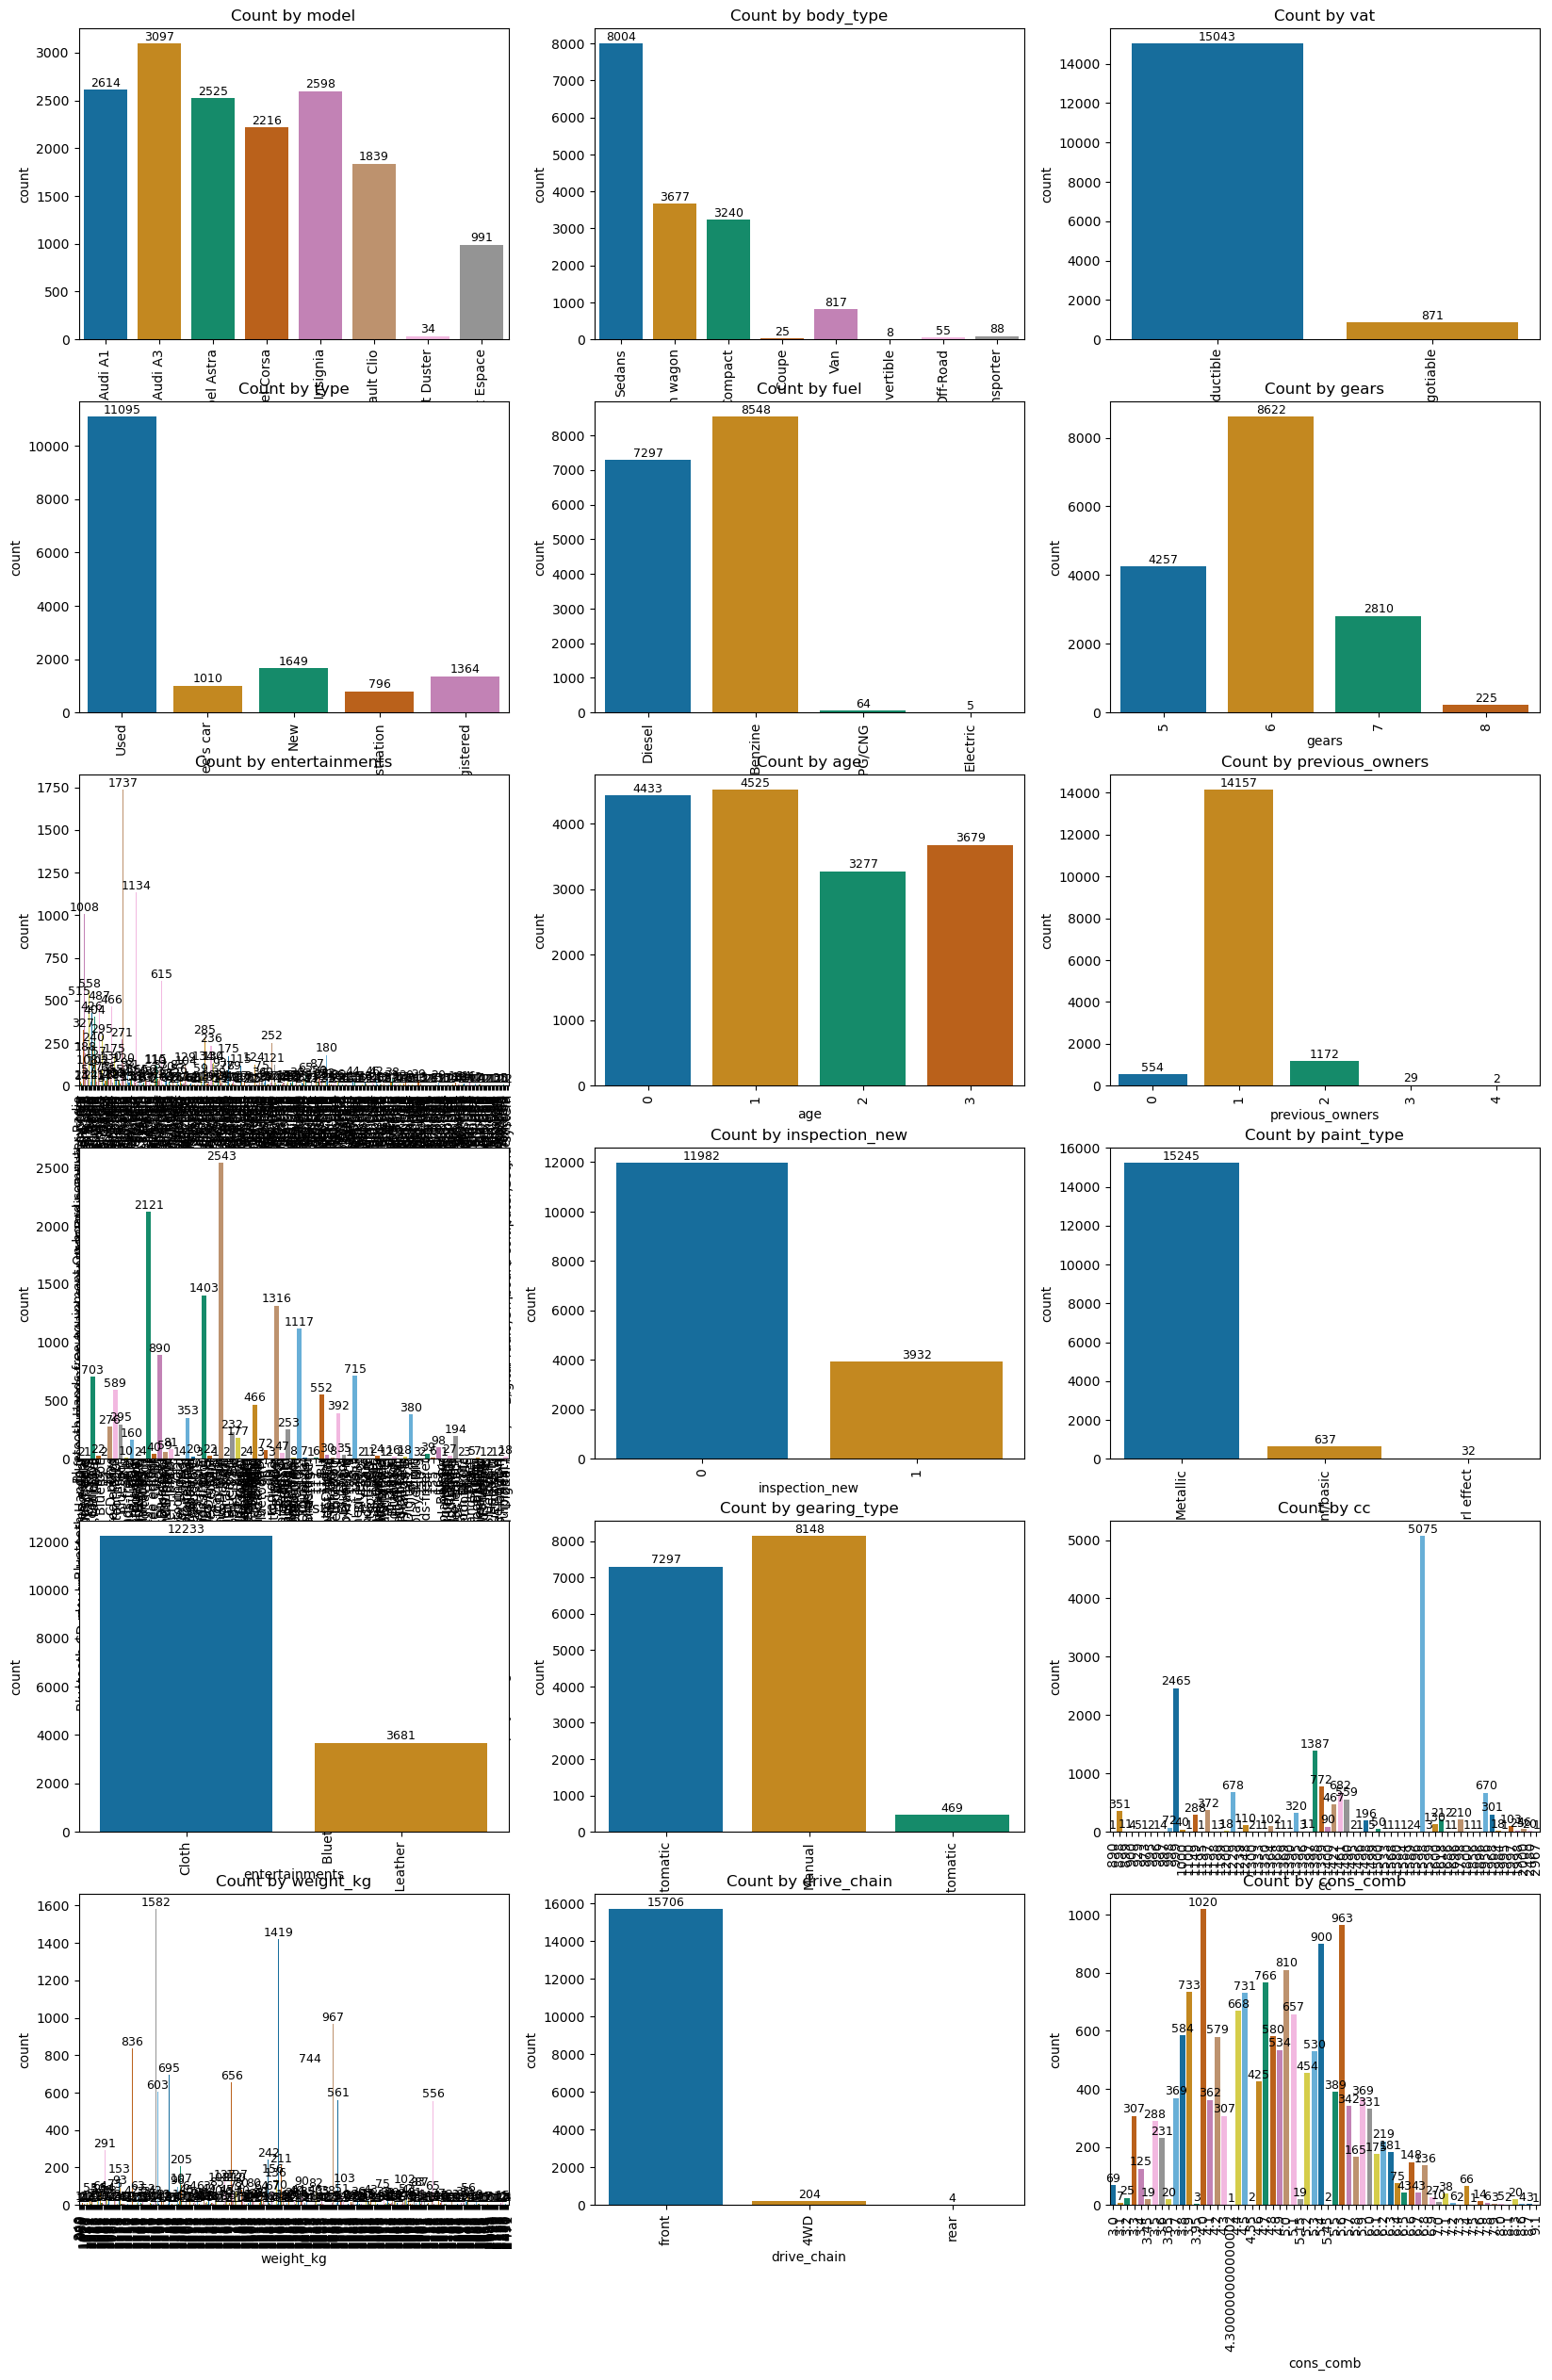

In [15]:
max_unique_values = 500

cols_to_plot = [col for col in df.columns if df[col].nunique() <= max_unique_values]

total_plots = len(cols_to_plot)

nrows = 6
ncols = 3

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 30))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    ax = axes[i]
    sns.countplot(x=col, data=df, palette="colorblind", ax=ax)
    ax.set_title(f"Count by {col}")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=9, color='black', xytext=(0, 5),
                    textcoords='offset points')

if total_plots < nrows * ncols:
    for j in range(total_plots, nrows * ncols):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

<div class="alert alert-warning alert-info" style="background-color: #FAF9F6; border: 5px solid #A9A9A9; border-radius: 10px;">
    <h3 style="font-weight: bold; color: darkblue;">Visualization</h3>
</div>

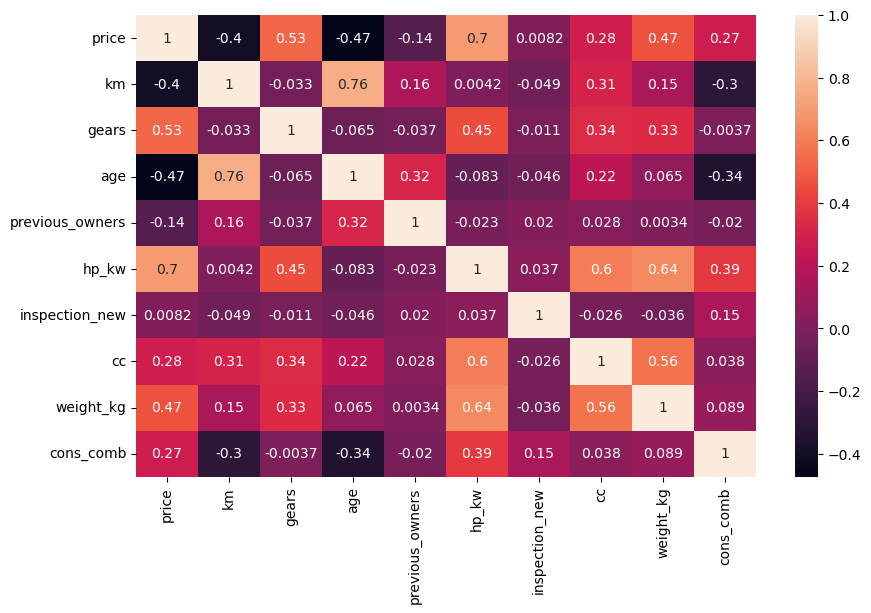

In [16]:
sns.heatmap(df.corr(numeric_only=True),annot=True);

In [17]:
def color_correlation1(val):
    """
    Takes a scalar and returns a string with
    the css property in a variety of color scales 
    for different correlations.
    """
    if val >= 0.6 and val < 0.99999 or val <= -0.6 and val > -0.99999:
        color = 'red'
    elif val < 0.6 and val >= 0.3 or val > -0.6 and val <= -0.3:
        color = 'blue'
    elif val == 1:
        color = 'green'    
    else:
        color = 'black'
    return 'color: %s' % color

numeric_df = df.select_dtypes(include=[np.number])

numeric_df.corr().style.applymap(color_correlation1)

,price,km,gears,age,previous_owners,hp_kw,inspection_new,cc,weight_kg,cons_comb
price,1.000000,-0.399301,0.530315,-0.473478,-0.144625,0.696465,0.008230,0.281791,0.468564,0.272270
km,-0.399301,1.000000,-0.033170,0.758306,0.157040,0.004216,-0.049449,0.306784,0.147093,-0.300198
gears,0.530315,-0.033170,1.000000,-0.064522,-0.036611,0.449794,-0.011093,0.339508,0.333945,-0.003733
age,-0.473478,0.758306,-0.064522,1.000000,0.316107,-0.083257,-0.045524,0.215283,0.064863,-0.341303
previous_owners,-0.144625,0.157040,-0.036611,0.316107,1.000000,-0.022557,0.019541,0.027964,0.003435,-0.020171
hp_kw,0.696465,0.004216,0.449794,-0.083257,-0.022557,1.000000,0.036603,0.597498,0.638323,0.388913
inspection_new,0.008230,-0.049449,-0.011093,-0.045524,0.019541,0.036603,1.000000,-0.025961,-0.035555,0.147818
cc,0.281791,0.306784,0.339508,0.215283,0.027964,0.597498,-0.025961,1.000000,0.563440,0.037811
weight_kg,0.468564,0.147093,0.333945,0.064863,0.003435,0.638323,-0.035555,0.563440,1.000000,0.088940
cons_comb,0.272270,-0.300198,-0.003733,-0.341303,-0.020171,0.388913,0.147818,0.037811,0.088940,1.000000


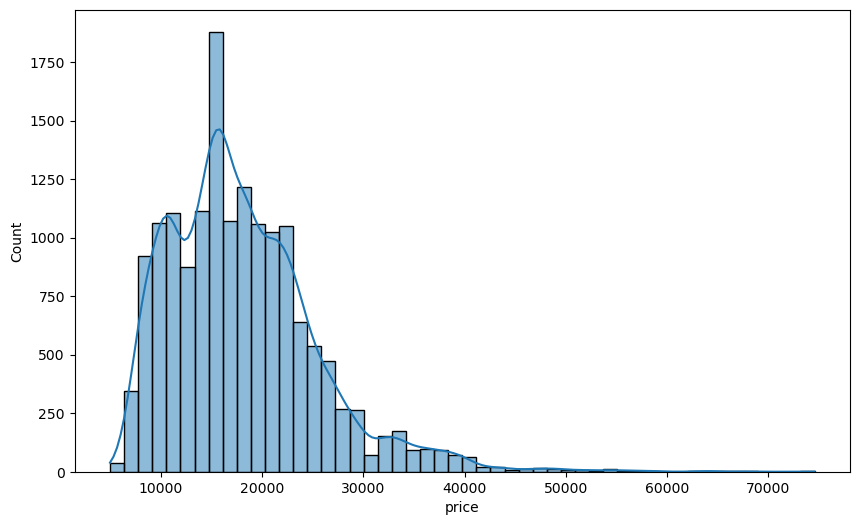

In [18]:
sns.histplot(df.price, bins=50, kde=True);

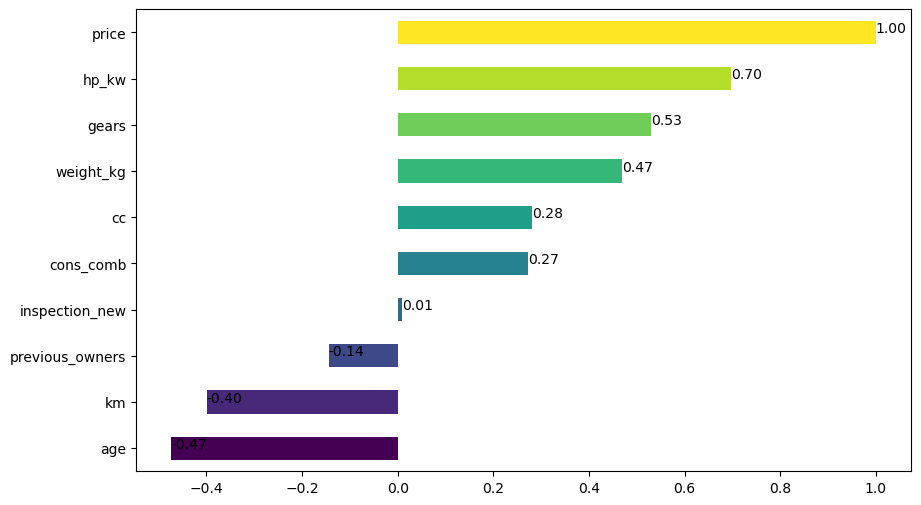

In [19]:
numeric_df = df.select_dtypes(include=[np.number])

corr_values = numeric_df.corr()["price"].sort_values()
colors = plt.cm.viridis(np.linspace(0, 1, len(corr_values)))

ax = corr_values.plot.barh(color=colors)
for index, value in enumerate(corr_values):
    plt.text(value, index, "{:.2f}".format(value))

plt.show()

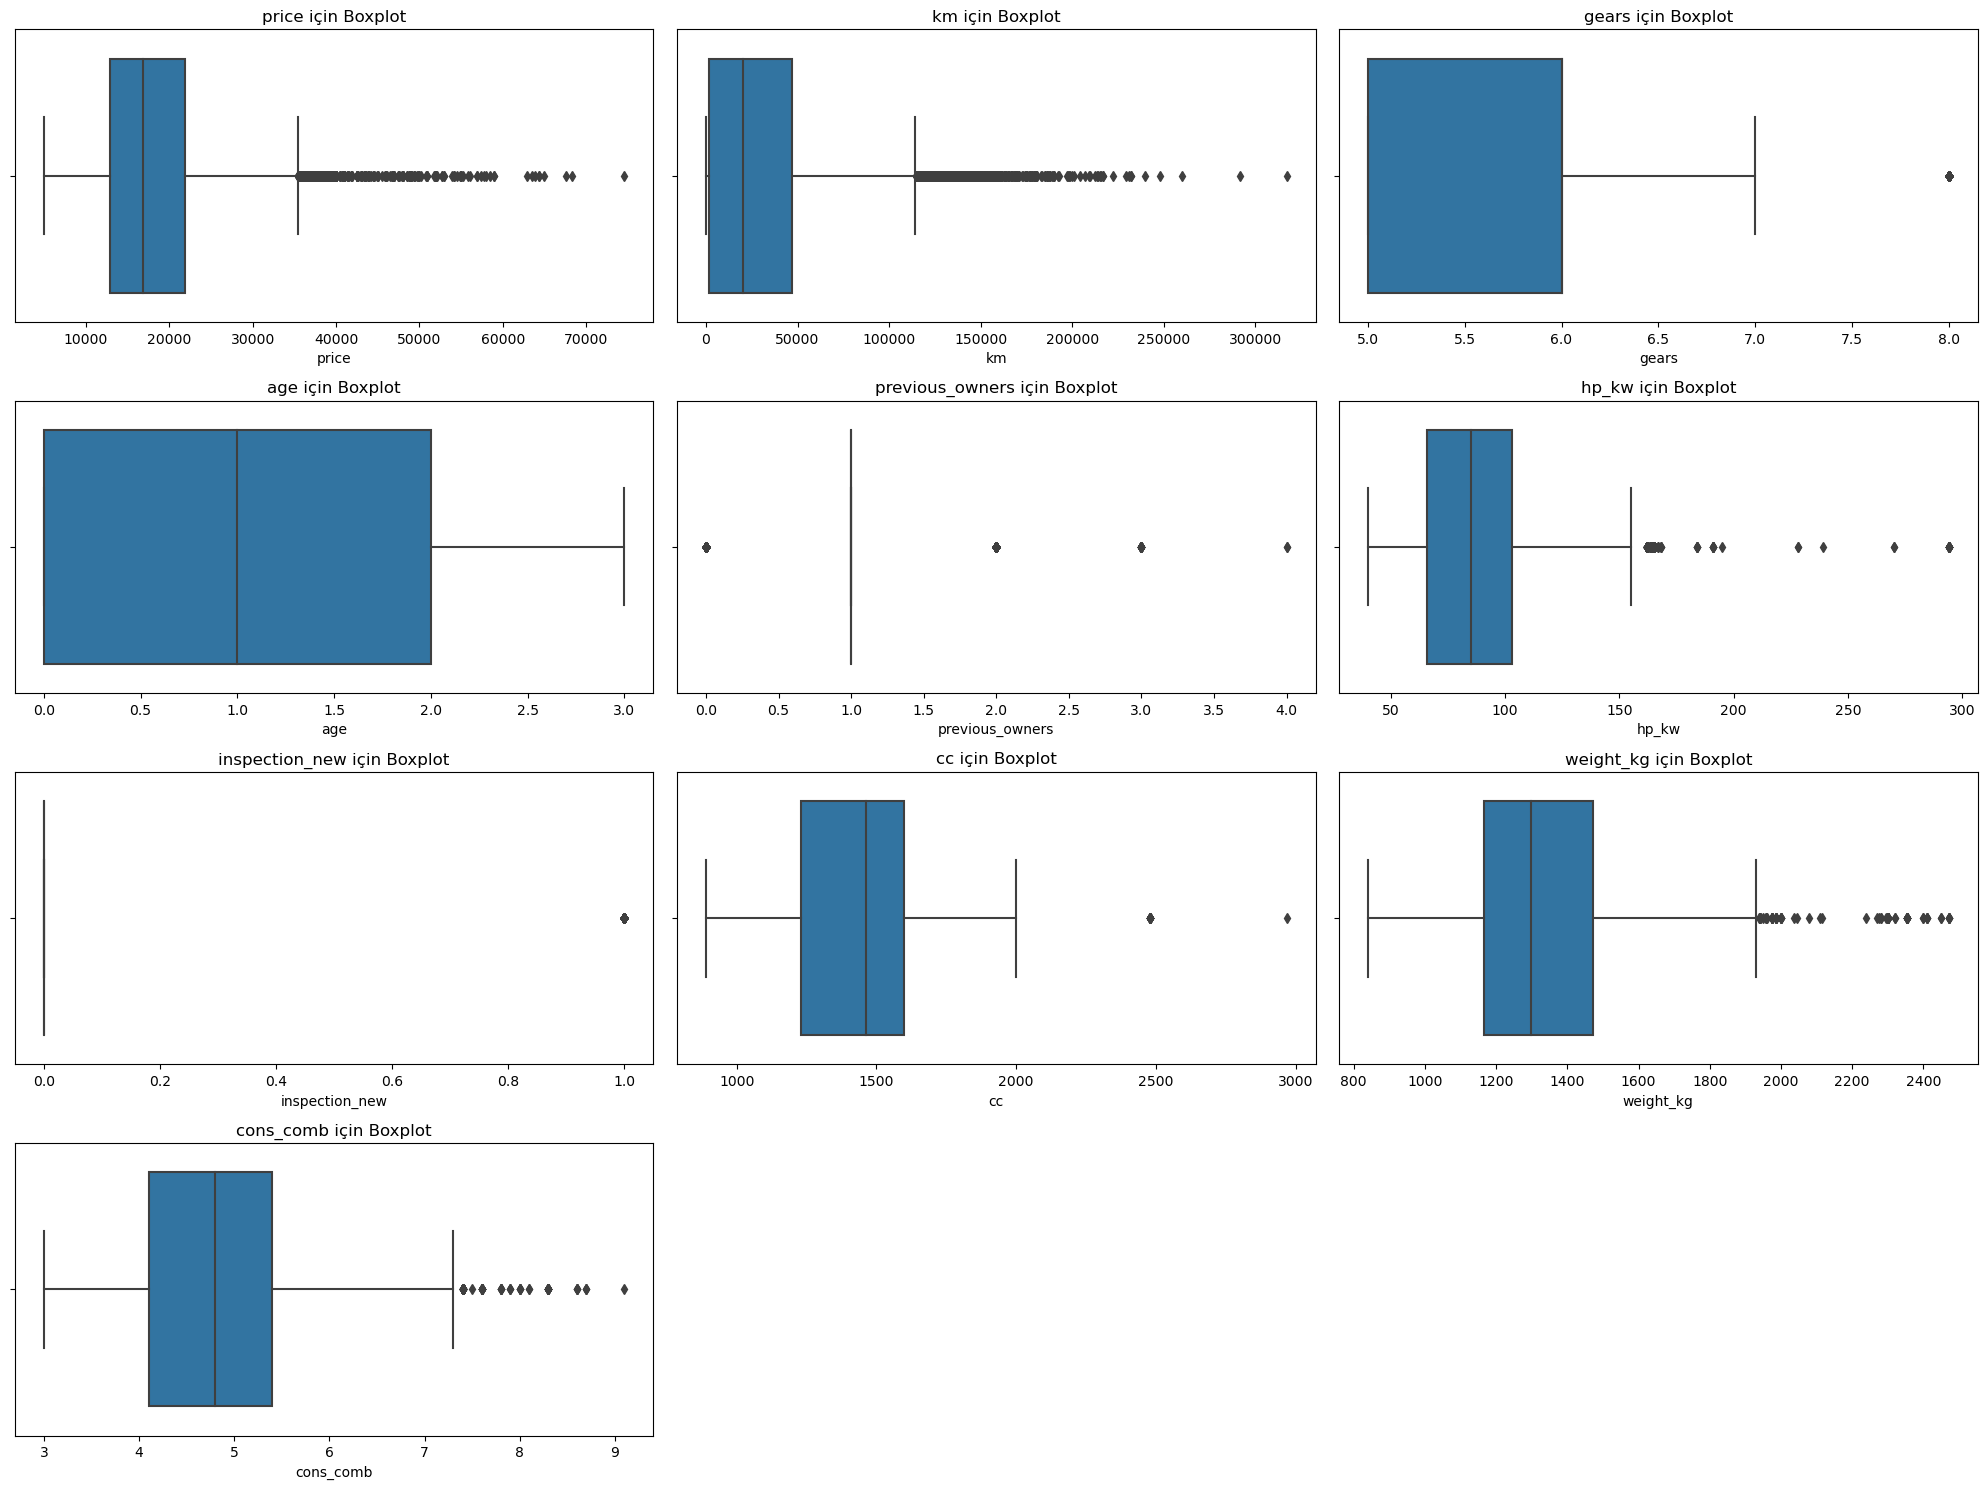

In [20]:
num_plots = len(numeric_df)

# 3x4'lük bir grid oluşturun
fig, axes = plt.subplots(4, 3, figsize=(20, 15))
axes = axes.flatten()  # Kolay iterasyon için düzleştirin

# Her sütun için boxplot oluşturun
for i, col in enumerate(numeric_df):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"{col} için Boxplot")

# Kullanılmayan eksenleri gizleyin
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 2. Data Pre-Processing

As you know, the data set must be edited before proceeding to the implementation of the model. As the last step before model fitting, you need to spilit the data set as train and test. Then, you should train the model with train data and evaluate the performance of the model on the test data. You can use the train and test data you have created for all algorithms.

You must also drop your target variable, the column you are trying to predict.

You can use many [performance metrics for regression](https://medium.com/analytics-vidhya/evaluation-metrics-for-regression-problems-343c4923d922) to measure the performance of the regression model you train. You can define a function to view different metric results together.

You can also use the [cross validation](https://towardsdatascience.com/cross-validation-explained-evaluating-estimator-performance-e51e5430ff85) method to measure the estimator performance. Cross validation uses different data samples from your test set and calculates the accuracy score for each data sample. You can calculate the final performance of your estimator by averaging these scores.

## 3. Implement Linear Regression

 - Import the modul
 - Fit the model 
 - Predict the test set
 - Determine feature coefficiant
 - Evaluate model performance (use performance metrics for regression and cross_val_score)
 - Compare different evaluation metrics
 
*Note: You can use the [dir()](https://www.geeksforgeeks.org/python-dir-function/) function to see the methods you need.*

## 4. Implement Ridge Regression

- Import the modul 
- Do not forget to scale the data or use Normalize parameter as True 
- Fit the model 
- Predict the test set 
- Evaluate model performance (use performance metrics for regression) 
- Tune alpha hiperparameter by using [cross validation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RidgeCV.html) and determine the optimal alpha value.
- Fit the model and predict again with the new alpha value. 

## 5. Implement Lasso Regression

- Import the modul 
- Do not forget to scale the data or use Normalize parameter as True(If needed)
- Fit the model 
- Predict the test set 
- Evaluate model performance (use performance metrics for regression) 
- Tune alpha hyperparameter by using [cross validation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LassoCV.html) and determine the optimal alpha value.
- Fit the model and predict again with the new alpha value.
- Compare different evaluation metrics

*Note: To understand the importance of the alpha hyperparameter, you can observe the effects of different alpha values on feature coefficants.*

## random state=42

## 6. Implement Elastic-Net

- Import the modul 
- Do not forget to scale the data or use Normalize parameter as True(If needed)
- Fit the model 
- Predict the test set 
- Evaluate model performance (use performance metrics for regression) 
- Tune alpha hyperparameter by using [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) and determine the optimal alpha value.
- Fit the model and predict again with the new alpha value.
- Compare different evaluation metrics

## random state = 42

## Feature Importance 

## 7. Visually Compare Models Performance In a Graph

## Prediction new observation

## random state=42

# !! (Dont forget Grid-Search)!!





# Congratulations